In [1]:
import pickle
import numpy as np
from src.simhash import SH

with open('data/arrays.pkl', 'rb') as f:
    arrays = pickle.load(f)

with open('data/arrays_queries.pkl', 'rb') as f:
    q = pickle.load(f)

arrays = [i[1] for i in arrays]
queries = [i[1] for i in q]

In [2]:
from tests.error_test import test_top_k_sketches, test_top_k_sketches_asym
from src.adaptive_separate_and_sketch import ASaS
from src.simhash import SH
from src.true_sample_and_sketch import Sample_and_sketch
from src.separate_and_sketch import SaS
from src.jl_cs import JL
from src.my_priority_sampling import PS

class SimpleJL:
    def __init__(self, size, seed):
        self.sketcher = JL(size // 64, seed)

    def sketch(self, vec):
        return self.sketcher.sketch(vec)

    def get_matrix(self):
        return self.sketcher.get_matrix()
    
class SimpleASaS:
    def __init__(self, size, seed):
        self.sketcher = ASaS(size, seed, SH, dim=arrays[0].shape[0])

    def sketch(self, vec):
        return self.sketcher.sketch(vec)

    def sketch_asym(self, vec):
        return self.sketcher.sketch_asym(vec)
    
    def get_matrix(self):
        return self.sketcher.get_matrix()
    

class SimpleSepareteAndSketch50:
    def __init__(self, size, seed):
        self.sketcher = SaS(int(0.5 * size), int(0.5 * size), seed, SH, dim=arrays[0].shape[0])
    def sketch(self, vec):
        return self.sketcher.sketch(vec)
    def sketch_asym(self, vec):
        return self.sketcher.sketch_asym(vec)    
    def get_matrix(self):
        return self.sketcher.get_matrix()
    
class SimpleSH:
    def __init__(self, size, seed):
        self.sketcher = SH(size, seed, dim=arrays[0].shape[0])
    def sketch(self, vec):
        return self.sketcher.sketch(vec)
    def sketch_asym(self, vec):
        return self.sketcher.sketch_asym(vec)
    def get_matrix(self):
        return self.sketcher.get_matrix()



In [3]:
from src.quantize_ps import PSQ

class SimplePSQ4:
    def __init__(self, size, seed):
        self.sketcher = PSQ(size, seed, key_size=4)

    def sketch(self, vec):
        return self.sketcher.sketch(vec)

    def get_matrix(self):
        return self.sketcher.get_matrix()

class SimplePSQ6:
    def __init__(self, size, seed):
        self.sketcher = PSQ(size, seed, key_size=6)

    def sketch(self, vec):
        return self.sketcher.sketch(vec)

    def get_matrix(self):
        return self.sketcher.get_matrix()

class SimplePSQ8:
    def __init__(self, size, seed):
        self.sketcher = PSQ(size, seed, key_size=8)

    def sketch(self, vec):
        return self.sketcher.sketch(vec)

    def get_matrix(self):
        return self.sketcher.get_matrix()
    
class SimplePSQ9:
    def __init__(self, size, seed):
        self.sketcher = PSQ(size, seed, key_size=9)

    def sketch(self, vec):
        return self.sketcher.sketch(vec)

    def get_matrix(self):
        return self.sketcher.get_matrix()
    
class SimplePSQ10:
    def __init__(self, size, seed):
        self.sketcher = PSQ(size, seed, key_size=10)

    def sketch(self, vec):
        return self.sketcher.sketch(vec)

    def get_matrix(self):
        return self.sketcher.get_matrix()
    
class SimplePSQ11:
    def __init__(self, size, seed):
        self.sketcher = PSQ(size, seed, key_size=11)

    def sketch(self, vec):
        return self.sketcher.sketch(vec)

    def get_matrix(self):
        return self.sketcher.get_matrix()
    

    
class SimplePSQ12:
    def __init__(self, size, seed):
        self.sketcher = PSQ(size, seed, key_size=12)

    def sketch(self, vec):
        return self.sketcher.sketch(vec)

    def get_matrix(self):
        return self.sketcher.get_matrix()
    
class SimplePSQ13:
    def __init__(self, size, seed):
        self.sketcher = PSQ(size, seed, key_size=13)

    def sketch(self, vec):
        return self.sketcher.sketch(vec)

    def get_matrix(self):
        return self.sketcher.get_matrix()
    
class SimplePSQ14:
    def __init__(self, size, seed):
        self.sketcher = PSQ(size, seed, key_size=14)

    def sketch(self, vec):
        return self.sketcher.sketch(vec)

    def get_matrix(self):
        return self.sketcher.get_matrix()
    
class SimplePSQ16:
    def __init__(self, size, seed):
        self.sketcher = PSQ(size, seed, key_size=16)

    def sketch(self, vec):
        return self.sketcher.sketch(vec)

    def get_matrix(self):
        return self.sketcher.get_matrix()
    
    
class SimplePSQ32:
    def __init__(self, size, seed):
        self.sketcher = PSQ(size, seed, key_size=32)

    def sketch(self, vec):
        return self.sketcher.sketch(vec)

    def get_matrix(self):
        return self.sketcher.get_matrix()

/home/gabriel/Documentos/QuantizedInnerProductSketching/src/quantize_ps.py:161: RuntimeWarning: divide by zero encountered in divide
  Ra = idx_hash / vector**2
/home/gabriel/Documentos/QuantizedInnerProductSketching/src/quantize_ps.py:100: RuntimeWarning: invalid value encountered in scalar multiply
  soma += i*j / min(1, i** 2 *ta, j **2 * tb)


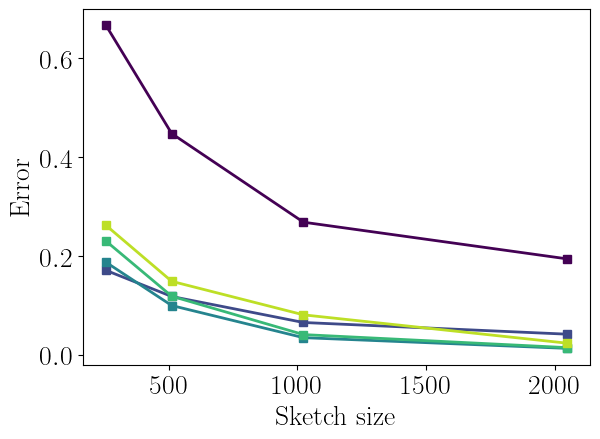

[[0.6674288664992253, 0.44790563349266294, 0.2683920388312805, 0.19414666313188284], [0.17095539378732735, 0.11793113189003496, 0.06525374333790612, 0.04159106585954354], [0.18740169920595853, 0.09961562471077727, 0.03453764839622425, 0.01286113935884744], [0.23037189328623128, 0.11844555642218321, 0.040760336105908415, 0.014348087653110296], [0.26220492947563745, 0.14864516899511446, 0.08075344540748092, 0.023386186321438324]]


In [4]:
print(test_top_k_sketches([SimplePSQ4, SimplePSQ8, SimplePSQ12, SimplePSQ16, SimplePSQ32],
                           [256, 512, 1024, 2048], 10, arrays, queries[:10], 1, ['4 bit key', '8 bit key', '12 bit key', '16 bit key', '32 bit key']
                           , "SPLADE top 1 quantization test", markers= ['s', 's', 's', 's', 's', 's', 's', 's']))

In [ ]:
import matplotlib.pyplot as plt

colors_wrong_order = plt.cm.viridis(np.linspace(0, 0.9, 4))
colors = [colors_wrong_order[1], colors_wrong_order[0], colors_wrong_order[2], colors_wrong_order[3]]


print(test_top_k_sketches([SimpleJL, SimpleSH, PS, SimplePSQ12],
                           [256, 512, 1024, 2048], 10, arrays, queries[:10], 1, ['Johnson–Lindenstrauss', 'SimHash', 'Priority Sampling', 'Priority Sampling Quantized'], "SPLADE top 1", markers= ['s', 's', '^', '^'], colors=colors))
print(test_top_k_sketches([SimpleJL, SimpleSH, PS, SimplePSQ12],
                           [256, 512, 1024, 2048], 10, arrays, queries[:10], 10, ['Johnson–Lindenstrauss', 'SimHash', 'Priority Sampling', 'Priority Sampling Quantized'], "SPLADE top 10", markers= ['s', 's', '^', '^'], colors=colors))
print(test_top_k_sketches([SimpleJL, SimpleSH, PS, SimplePSQ12],
                           [256, 512, 1024, 2048], 10, arrays, queries[:10], 100, ['Johnson–Lindenstrauss', 'SimHash', 'Priority Sampling', 'Priority Sampling Quantized'], "SPLADE top 100", markers= ['s', 's', '^', '^'], colors=colors))

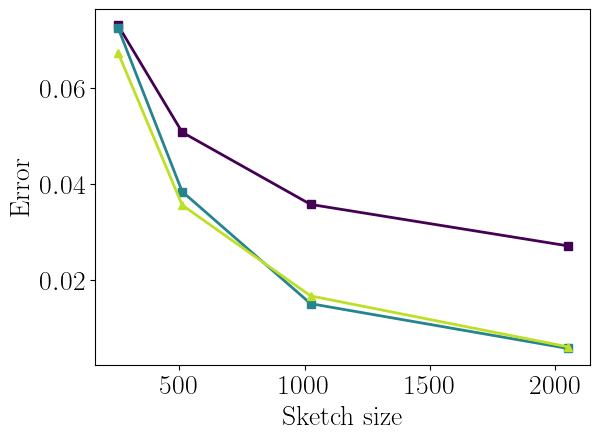

[[0.07305286633475357, 0.05073471734414088, 0.0357014928822962, 0.027079291128412487], [0.07254548624733315, 0.038372395755302005, 0.015020551065619014, 0.005708658905185086], [0.0673531808014429, 0.035568852709070786, 0.016637077855359724, 0.00604413873479414]]


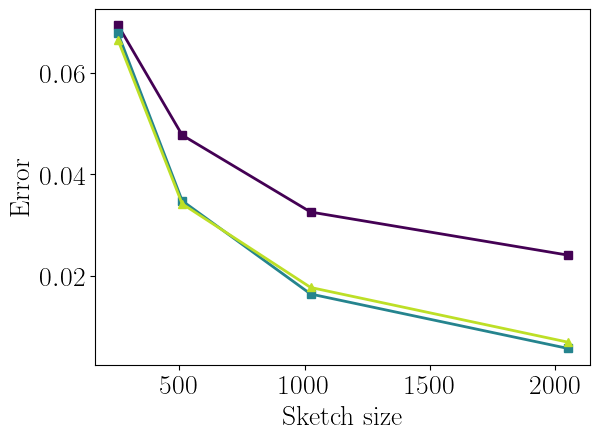

[[0.06936225444324516, 0.047705732807272055, 0.03256137107412166, 0.02408973934579333], [0.06775832596086538, 0.03476863629126952, 0.016415413291231563, 0.005713672590549724], [0.06646313737572357, 0.034171101936156204, 0.017704435005157997, 0.006952443213569367]]


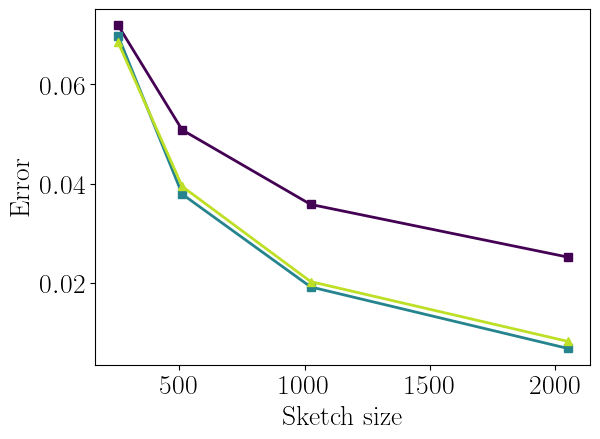

[[0.07194743279783598, 0.050810305532200034, 0.03578226370565862, 0.02516724272867528], [0.06985158726683331, 0.03785486288006862, 0.01913823210580442, 0.006741786689009294], [0.06854436492196142, 0.03940762805739411, 0.02021642400298451, 0.00816278143198656]]


In [6]:
print(test_top_k_sketches([SimpleSH, SimpleASaS, SimpleSepareteAndSketch50],
                           [256, 512, 1024, 2048], 10, arrays, queries[:10], 1, ['SimHash', 'Adaptive Select and Sketch', 'Priority Sampling', 'JL'], "ASAS SPLADE top 1", markers= ['s', 's', '^', '^']))
print(test_top_k_sketches([SimpleSH, SimpleASaS, SimpleSepareteAndSketch50],
                           [256, 512, 1024, 2048], 10, arrays, queries[:10], 10, ['SimHash', 'Adaptive Select and Sketch', 'Priority Sampling', 'JL'], "ASAS SPLADE top 10", markers= ['s', 's', '^', '^']))
print(test_top_k_sketches([SimpleSH, SimpleASaS, SimpleSepareteAndSketch50],
                           [256, 512, 1024, 2048], 10, arrays, queries[:10], 100, ['SimHash', 'Adaptive Select and Sketch', 'Priority Sampling', 'JL'], "ASAS SPLADE top 100", markers= ['s', 's', '^', '^']))

In [9]:
nnz_avg = 0

for array in arrays:
    nnz_avg += np.count_nonzero(array.toarray()) / len(array.toarray())

print(nnz_avg / len(arrays))

0.0039210564733153765
